Accuracy: 0.7359307359307359

Confusion Matrix:
 [[120  31]
 [ 30  50]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.79      0.80       151
           1       0.62      0.62      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231



C:\Users\anjan\anaconda4\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


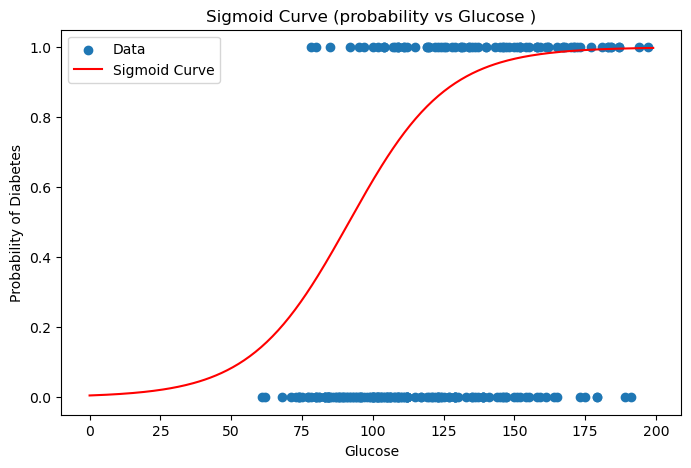

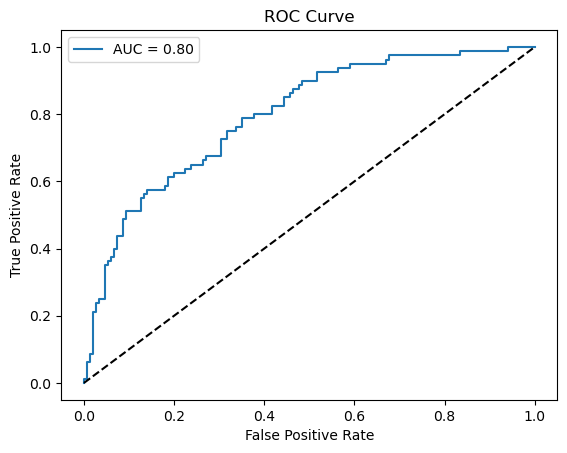

In [5]:
#Predict whether a patient has diabetes based on diagnostic measurements.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# --- 1) Load dataset ---
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness",
        "Insulin","BMI","DiabetesPedigree","Age","Outcome"]
df = pd.read_csv(url, names=cols)

# Features & target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# --- 2) Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --- 3) Model Training ---
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# --- 4) Predictions ---
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # prob of class 1

# --- 5) Evaluation Metrics ---
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", acc)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

# --- 6) Sigmoid Curve for one feature ---
feat = "Glucose"  # choose one feature to plot
x_vals = np.linspace(X[feat].min(), X[feat].max(), 300).reshape(-1, 1)

# reshape other features to their mean
mean_values = X.drop(feat, axis=1).mean().values
X_plot = np.hstack([x_vals, np.repeat(mean_values.reshape(1,-1), len(x_vals), axis=0)])

# sigmoid probabilities
sigmoid_probs = model.predict_proba(X_plot)[:, 1]

plt.figure(figsize=(8, 5))
plt.scatter(X_test[feat], y_test, label="Data")
plt.plot(x_vals, sigmoid_probs, color="red", label="Sigmoid Curve")
plt.xlabel(feat)
plt.ylabel("Probability of Diabetes")
plt.title("Sigmoid Curve (probability vs "+feat+" )")
plt.legend()
plt.show()

# --- 7) ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [2]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Dataset
X = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)  # study hours
y = np.array([0, 0, 0, 1, 1, 1])                # pass/fail

# Model
model = LogisticRegression()
model.fit(X, y)

# Predict probability
prob = model.predict_proba([[3.5]])
print("Probability of passing:", prob[0][0],prob[0][1])

# Predict class
prediction = model.predict([[3.5]])
print("Predicted class (0=Fail, 1=Pass):", prediction[0])

Probability of passing: 0.4999676295348402 0.5000323704651598
Predicted class (0=Fail, 1=Pass): 1
